# Walmart Sales Data Analysis

#### By Aaron Villegas

## Objective

The goal of this project is to analyze Walmart’s weekly sales data to identify key drivers of revenue, including seasonality, store performance, and the impact of holidays. 

The analysis aims to uncover actionable insights that can support business decisions such as inventory planning, staffing, and sales forecasting.

## Data Overview

The dataset contains weekly sales data for 45 Walmart stores.

- Time Period: Feb 2010 – Oct 2012  
- Number of Stores: 45  
- Number of Records: ~40,000  
- Key Features:
  - `weekly_sales`: Total sales per store per week  
  - `holiday_flag`: Indicates whether the week includes a holiday  
  - `temperature`, `fuel_price`, `cpi`, `unemployment`: External economic factors  

The data includes both internal store performance metrics and external variables for analysis.

## KPI Summary

| Metric                     | Value        |
|--------------------------|-------------|
| Total Sales              | $X          |
| Avg Weekly Sales         | $Y          |
| Number of Stores         | 45          |
| Holiday Sales Increase   | Z%          |

## Data Processing

In [ ]:
import sys, os
import pandas as pd
from dotenv import load_dotenv
load_dotenv()
sys.path.append(os.path.abspath('..'))
from src.data_loader import load_postgres, load_walmart_data, load_sql_with_fallback

engine_url = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"

df = load_walmart_data()
print(df.head())

Loaded data from PostgreSQL
   store        date  weekly_sales  holiday_flag  temperature  fuel_price  \
0      1  2010-02-05    1643690.90         False        42.31        2.57   
1      1  2010-02-12    1641957.44          True        38.51        2.55   
2      1  2010-02-19    1611968.17         False        39.93        2.51   
3      1  2010-02-26    1409727.59         False        46.63        2.56   
4      1  2010-03-05    1554806.68         False        46.50        2.63   

       cpi  unemployment  
0  211.096         8.106  
1  211.242         8.106  
2  211.289         8.106  
3  211.320         8.106  
4  211.350         8.106  


## Do holidays increase sales?

In [ ]:
query = """
SELECT 
    holiday_flag, 
    AVG(weekly_sales) AS avg_weekly_sales
FROM sales
GROUP BY  holiday_flag
ORDER BY avg_weekly_sales DESC;
"""
df_result1 = load_sql_with_fallback(query)
print("Query result preview:")
print(df_result1)
print("Average percent increase in holiday sales, holiday vs non-holiday: ", 
      (df_result1.loc[df_result1['holiday_flag'] == 1, 'avg_weekly_sales'].values[0] - df_result1.loc[df_result1['holiday_flag'] == 0, 'avg_weekly_sales'].values[0]) / df_result1.loc[df_result1['holiday_flag'] == 0, 'avg_weekly_sales'].values[0] * 100, "%")

NameError: name 'load_sql_with_fallback' is not defined

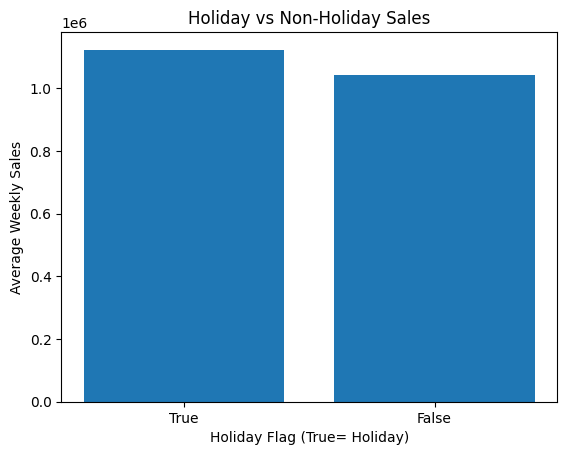

In [9]:
import matplotlib.pyplot as plt

plt.bar(df_result1['holiday_flag'].astype(str), df_result1['avg_weekly_sales'])
plt.xlabel("Holiday Flag (True= Holiday)")
plt.ylabel("Average Weekly Sales")
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

#### Does the effect vary by store?

In [5]:
query = """
SELECT 
    store, 
    AVG(CASE WHEN holiday_flag THEN weekly_sales END) AS avg_holiday_sales,
    AVG(CASE WHEN NOT holiday_flag THEN weekly_sales END) AS avg_non_holiday_sales,
    AVG(CASE WHEN holiday_flag THEN weekly_sales END) - AVG(CASE WHEN NOT holiday_flag THEN weekly_sales END) AS sales_diff
FROM sales
GROUP BY store
ORDER BY sales_diff DESC;
"""
df_result = load_postgres(query, engine_url)
# print("Query result preview:")
# print(df_result)

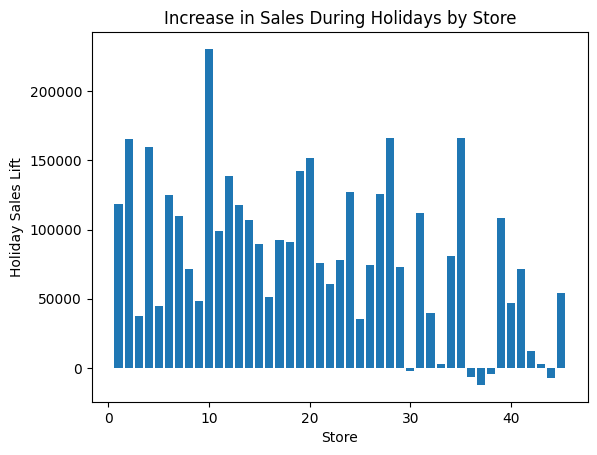

In [10]:
plt.bar(df_result['store'], df_result['sales_diff'])
plt.xlabel("Store")
plt.ylabel("Holiday Sales Lift")
plt.title("Increase in Sales During Holidays by Store")
plt.show()

Some stores have very high differences between holiday-week sales and non-holiday-week sales, but almost all stores have an increase in sales on holidays. 

#### Which stores generate the most sales?

In [7]:
query = """
SELECT 
    store, 
    SUM(weekly_sales) AS total_weekly_sales
FROM sales
GROUP BY store
ORDER BY total_weekly_sales DESC;
"""
df_result3 = load_postgres(query, engine_url)
print("Query result preview:")
print(df_result3.head())

Query result preview:
   store  total_weekly_sales
0     20        6.027956e+08
1      4        5.990879e+08
2     14        5.779998e+08
3     13        5.730354e+08
4      2        5.507649e+08


Stores 20, 4, 14, 13, and 2 are the highest earning stores out of the 45 Walmart stores in the dataset.

#### Do factors such as temperature, fuel price, or consumer price index (CPI) correlate with weekly sales?

In [8]:
query = """
SELECT 
    CORR(weekly_sales, temperature) AS temp_corr,
    CORR(weekly_sales, fuel_price) AS fuel_corr,
    CORR(weekly_sales, unemployment) AS unemployment_corr,
    CORR(weekly_sales, cpi) AS cpi_corr
FROM sales;
"""
df_result4 = load_postgres(query, engine_url)
print("Query result preview:")
print(df_result4.head())

Query result preview:
   temp_corr  fuel_corr  unemployment_corr  cpi_corr
0   -0.06381   0.009483          -0.106176 -0.072634


Overall, since the correlation coefficients are near 0, temperature, fuel price, and consumer price index has little effect on weekly sales.  
However, perhaps it depends on the store.

In [12]:
# query = """
# SELECT 
#     store, 
#     CORR(weekly_sales, temperature) AS temp_corr,
#     CORR(weekly_sales, fuel_price) AS fuel_corr,
#     CORR(weekly_sales, unemployment) AS unemployment_corr,
#     CORR(weekly_sales, cpi) AS cpi_corr
# FROM sales
# GROUP BY store;
# """
# df_result5 = load_postgres(query, engine_url)
# print("Query result preview:")
# print(df_result5.head())

In [11]:
# import math
# df = df_result5  # your query result
# factors = ['Temp', 'Fuel', 'Unemployment', 'CPI']

# num_stores = len(df)
# cols = 5  # number of charts per row
# rows = math.ceil(num_stores / cols)

# fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 5*rows), sharey=True)
# axes = axes.flatten()  # flatten in case rows*cols > num_stores

# for ax, (_, row) in zip(axes, df.iterrows()):
#     values = [row['temp_corr'], row['fuel_corr'], row['unemployment_corr'], row['cpi_corr']]
#     ax.barh(factors, values, color=['skyblue', 'orange', 'green', 'red'])
#     ax.set_xlim(-1, 1)
#     ax.set_title(f'Store {row["store"]}')

# # Hide any extra axes if num_stores < rows*cols
# for ax in axes[num_stores:]:
#     ax.axis('off')

# fig.suptitle('Correlation of Factors with Weekly Sales per Store', fontsize=16)
# fig.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()

From analysis store-level correlations between weekly sales and temperature, unemployment, fuel, and CPI, some stores have stronger correlations between weekly sales and these external factors. This can be useful when training a predictive or forecasting model on sales, and can guide inventory management with the predicted number of weekly sales using these external factors as a predictive indicator.

#### Which stores are more consistent vs more volatile?

In [13]:
query6 = """
SELECT 
    store,
    STDDEV(weekly_sales) AS sales_stddev
FROM sales
GROUP BY store
ORDER BY sales_stddev DESC;
"""
df_result6 = load_postgres(query6, engine_url)
# print("Most volatile stores:")
# print(df_result6.head())#Most volatile stores based on standard deviation of weekly sales
# print("Least volatile stores:")
# print(df_result6.tail())#Least volatile stores based on standard deviation of weekly sales

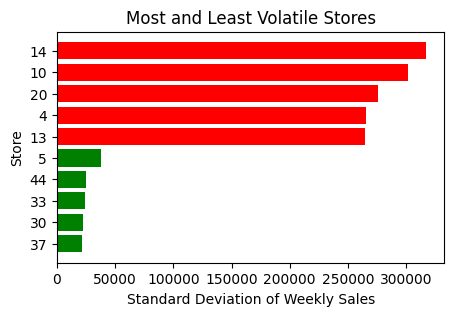

In [12]:
# Sort by volatility
df_sorted = df_result6.sort_values('sales_stddev', ascending=False)

# Pick top 5 most volatile and bottom 5 least volatile
top_5 = df_sorted.head(5)
bottom_5 = df_sorted.tail(5)

# Combine for plotting
df_plot = pd.concat([top_5, bottom_5])

# Create a horizontal bar chart
plt.figure(figsize=(5,3))
plt.barh(df_plot['store'].astype(str), df_plot['sales_stddev'], color=['red']*5 + ['green']*5)
plt.xlabel('Standard Deviation of Weekly Sales')
plt.ylabel('Store')
plt.title('Most and Least Volatile Stores')
plt.gca().invert_yaxis()  # optional: largest value on top
plt.show()

According to the standard deviation of the stores' weekly sales data, stores 14, 19, 20, 4, and 13 are the most volatile while stores 5, 44, 33, 30, and 37 are the least volatile. However, measuring variation by just standard deviation may be misleading since smaller stores that sell less on average would a less magnitude of variation. Thus, a more useful metric is the coefficient of variation (CV), defined as the standard deviation divided by the mean.

In [13]:
query7 = """
SELECT 
    store,
    STDDEV(weekly_sales) / AVG(weekly_sales) AS sales_cv
FROM sales
GROUP BY store
ORDER BY sales_CV DESC;
""" 
df_result7 = load_postgres(query7, engine_url)

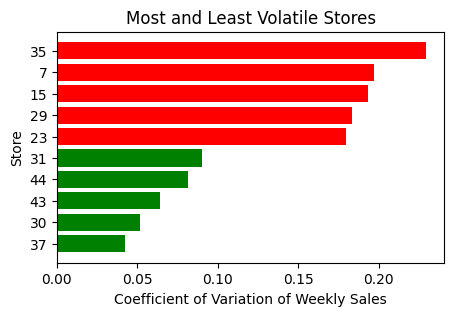

In [14]:
# Sort by CV
df_sorted = df_result7.sort_values('sales_cv', ascending=False)

# Pick top 5 most volatile and bottom 5 least volatile
top_5 = df_sorted.head(5)
bottom_5 = df_sorted.tail(5)

# Combine for plotting
df_plot = pd.concat([top_5, bottom_5])

# Create a horizontal bar chart
plt.figure(figsize=(5,3))
plt.barh(df_plot['store'].astype(str), df_plot['sales_cv'], color=['red']*5 + ['green']*5)
plt.xlabel('Coefficient of Variation of Weekly Sales')
plt.ylabel('Store')
plt.title('Most and Least Volatile Stores')
plt.gca().invert_yaxis()  # optional: largest value on top
plt.show()

According to the coefficient of variability (CV), a measure of relative volatility, the most volatile stores are stores 35, 7, 15, 29, and 23 (different from before). The least volatile stores are stores 31, 44, 43, 30, and 37 (44, 30, and 37 were the least volatile according to standard deviation as well). Variance is an important factor in forecasting sales and deciding inventory and staffing since more variability makes it harder to make predictions on weekly sales or future growth and requires a more flexible inventory. More variance also introduces more risk into the business since it is harder to predict sales and manage inventory, and thus more likely to have overstock or understock.

### Trends in sales over time

In [53]:
query8 = """
SELECT 
    date,
    SUM(weekly_sales) AS total_sales
FROM sales
GROUP BY date
ORDER BY date;
"""
df_result8 = load_postgres(query8, engine_url)

#### Running average to smooth out data

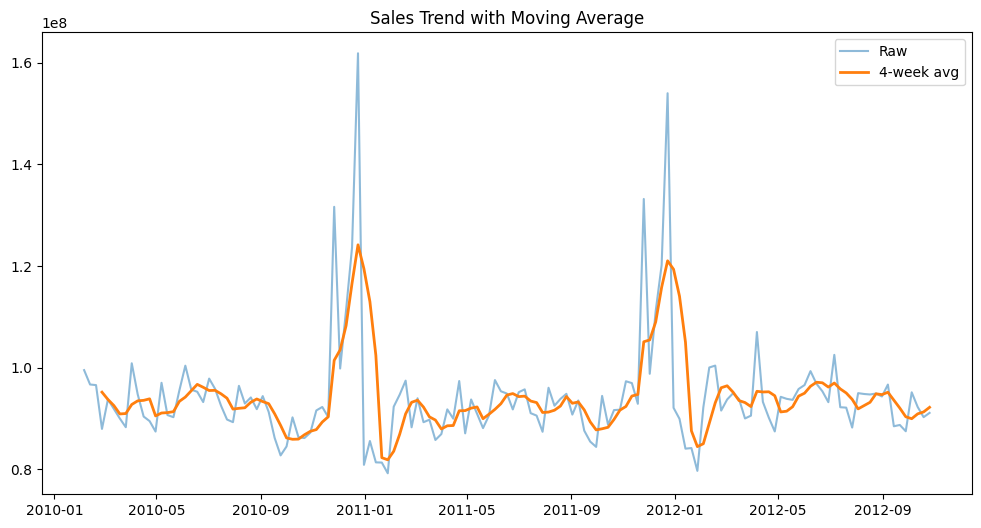

In [ ]:
df_result8['rolling_avg'] = df_result8['total_sales'].rolling(window=4).mean()

plt.figure(figsize=(12,6))
plt.plot(df_result8['date'], df_result8['total_sales'], alpha=0.5, label='Raw')
plt.plot(df_result8['date'], df_result8['rolling_avg'], linewidth=2, label='4-week avg')
plt.legend()
plt.title('Sales Trend with Moving Average')
plt.show()

In [20]:
df_result8_sorted = df_result8.sort_values('total_sales', ascending=False)
df_result8_sorted.head(10)

,date,total_sales
46,2010-12-24,1.618628e+08
98,2011-12-23,1.539965e+08
94,2011-11-25,1.331872e+08
42,2010-11-26,1.316420e+08
45,2010-12-17,1.236416e+08
97,2011-12-16,1.201714e+08
44,2010-12-10,1.113335e+08
96,2011-12-09,1.111223e+08
113,2012-04-06,1.070046e+08
126,2012-07-06,1.025060e+08


In [22]:
df_result8_sorted.tail(10).sort_values('total_sales', ascending=True).head(10)

,date,total_sales
51,2011-01-28,79199705.98
103,2012-01-27,79669949.34
47,2010-12-31,80865038.00
50,2011-01-21,81309296.06
49,2011-01-14,81347356.08
33,2010-09-24,82717028.82
101,2012-01-13,84046156.96
102,2012-01-20,84161993.12
86,2011-09-30,84391661.62
34,2010-10-01,84479751.74


From the graph above, we can see there are some consistent trends over time. There are some peaks in sales around the end of the year, which could be due to the holiday season around Christmas and Black Friday. The lowest periods of sales are around mid-January and include holidays such as Thanksgiving Day and Christmas, since most Walmarts are closed on those days.

#### Monthly sales trends

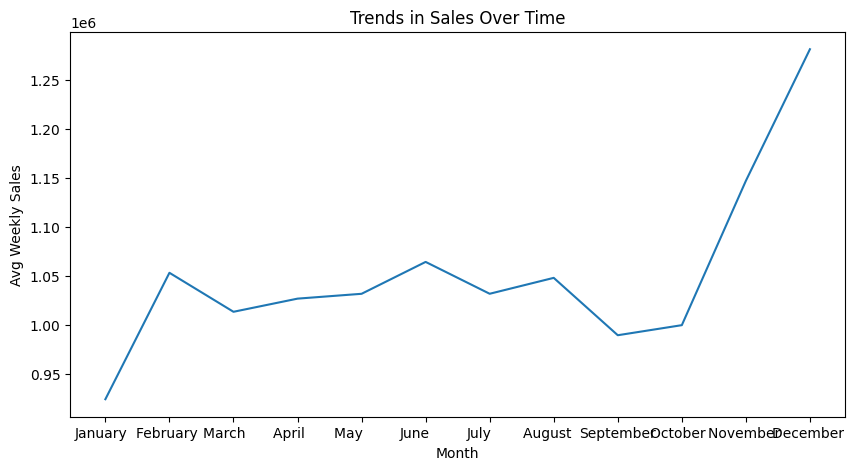

In [45]:
query9 = """
SELECT
    EXTRACT (MONTH FROM date) AS month,
    TO_CHAR(date, 'Month') AS month_name,
    AVG(weekly_sales) AS avg_sales
FROM sales
GROUP BY month_name, month
ORDER BY month;
"""
df_result9 = load_postgres(query9, engine_url)
plt.figure(figsize=(10,5))
plt.plot(df_result9['month_name'], df_result9['avg_sales'])
plt.xlabel('Month')
plt.ylabel('Avg Weekly Sales')
plt.title('Trends in Sales Over Time')
plt.show()

#### Trends in sales over time by store

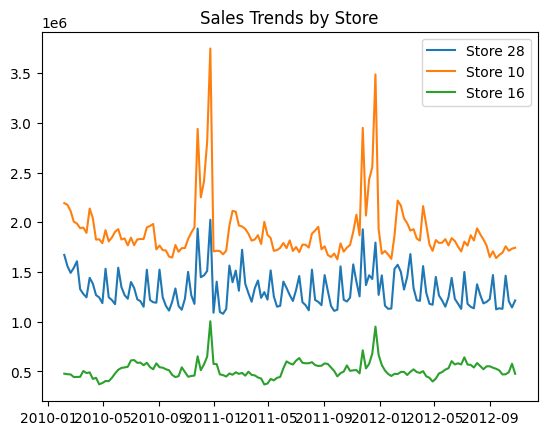

In [42]:
query10 = """
SELECT 
    store, 
    date,
    weekly_sales
FROM sales
ORDER BY date;
"""
df_result10 = load_postgres(query10, engine_url)
df = df_result10.copy()
for store_id in df['store'].unique()[:3]:  # just 3 stores
    subset = df[df['store'] == store_id]
    subset['date'] = pd.to_datetime(subset['date'], dayfirst=True)
    
    plt.plot(subset['date'], subset['weekly_sales'], label=f'Store {store_id}')

plt.legend()
plt.title('Sales Trends by Store')
plt.show()

We can see that the sales trends also varies by store but follows a similar patterns with similar peaks during holiday seasons. Some stores have more pronounced peaks than others, which could be due to the location of the store and how much it is affected by the holiday season. For example, stores in more urban areas may have more pronounced peaks during the holiday season compared to stores in more rural areas.

### Business Recommendations
• Increase inventory and staffing during holiday periods due to consistent sales spikes  
• Focus on high-performing stores for revenue growth strategies  
• Apply flexible inventory planning for high-volatility stores  
• Use store-specific strategies instead of relying solely on macroeconomic indicators or overall trends, since some stores have stronger correlations with external factors than others.